### 0. Library Imports

In [1]:
import re
import random
import pandas as pd
import numpy as np
import csv
from pathlib import Path

import math
from collections import defaultdict
from scipy.sparse import lil_matrix

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel, BertTokenizerFast, BertForSequenceClassification

import gensim.downloader as api
from gensim.models import Word2Vec, FastText

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Set Device type

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


### 2. Load Dataset

In [3]:
df = pd.read_csv('dataset/support-ticket-classification.csv')

y = np.array(df['label'].values)
unique_labels = sorted(df['label'].unique().tolist())

print(f"Dataset loaded: {df.shape}")
print(f"Classes: {unique_labels}")
print(f"Class distribution:\n{df['label'].value_counts()}\n")

Dataset loaded: (2000, 4)
Classes: ['account_access', 'billing', 'bug_report', 'refund_request', 'shipping_delivery']
Class distribution:
label
account_access       400
billing              400
refund_request       400
bug_report           400
shipping_delivery    400
Name: count, dtype: int64



### 3. Preprocessing Steps

In [4]:
def load_stopwords(file_path):
    stopwords = set()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().lower()
            if word and not word.startswith('#'):
                stopwords.add(word)
    return stopwords

stopwords = load_stopwords('dataset/stopwords.txt')

for w in ['the', 'is', 'account', 'billing', 'login', 'and', 'password']:
    print(f"{w} -> stopword: {w in stopwords}")

the -> stopword: True
is -> stopword: True
account -> stopword: False
billing -> stopword: False
login -> stopword: False
and -> stopword: True
password -> stopword: False


In [5]:
def load_exc_files(noun_file, verb_file):
    exc_map = {}
    for file_path in [noun_file, verb_file]:
        if not Path(file_path).exists():
            continue
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    exc_map[parts[0]] = parts[1]
    return exc_map

exc_map = load_exc_files('dataset/wordnet_noun.exc', 'dataset/wordnet_verb.exc')

for word in ['men', 'mice', 'geese', 'ran', 'is']:
    if word in exc_map:
        print(f"{word} -> {exc_map[word]}")

men -> man
mice -> mouse
geese -> goose
ran -> run
is -> be


In [6]:
def load_lemma_dict(file_path):
    lemma_map = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';') or ' -> ' not in line:
                continue
            lemma_part, _, forms_part = line.partition(' -> ')
            lemma = lemma_part.split('/')[0].strip()
            for form in forms_part.split(','):
                form = form.strip()
                if form and re.match(r'^[a-z0-9]+$', form) and form not in lemma_map:
                    lemma_map[form] = lemma
    return lemma_map

lemma_map = load_lemma_dict('dataset/lemma.en.txt')
print(f"lemma_map loaded: {len(lemma_map)} entries\n")

for word in ['running', 'categories', 'responses', 'presses']:
    print(f"{word} -> {lemma_map.get(word, '(not found)')}")

lemma_map loaded: 90502 entries

running -> run
categories -> category
responses -> response
presses -> press


In [7]:
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "don't": "do not",
    "doesn't": "does not", "didn't": "did not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "you're": "you are", "we're": "we are",
    "they're": "they are", "it's": "it is", "that's": "that is",
    "there's": "there is", "i've": "i have", "we've": "we have",
    "they've": "they have", "shouldn't": "should not", "couldn't": "could not",
    "wouldn't": "would not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not",
}

for k, v in list(CONTRACTIONS.items())[:3]:
    print(f"{k} -> {v}")

can't -> cannot
won't -> will not
don't -> do not


In [8]:
DOMAIN_PHRASE_MAP = {
    "log in": "login", "sign in": "login",
    "wireless": "wifi", "wifi": "wifi",
    "remote access": "vpn", "vpn": "vpn",
    "mfa": "mfa", "2fa": "mfa",
}

DOMAIN_TOKEN_MAP = {
    "pls": "please", "plz": "please", "asap": "urgent",
    "u": "you", "ur": "your", "pwd": "password",
    "acct": "account", "acc": "account", "auth": "authentication",
    "db": "database", "srv": "server", "msg": "message",
    "req": "request", "otp": "onetimepassword", "2fa": "mfa",
}

for k, v in list(DOMAIN_PHRASE_MAP.items())[:3]:
    print(f"phrase  {k} -> {v}")
for k, v in list(DOMAIN_TOKEN_MAP.items())[:3]:
    print(f"token   {k} -> {v}")

phrase  log in -> login
phrase  sign in -> login
phrase  wireless -> wifi
token   pls -> please
token   plz -> please
token   asap -> urgent


In [9]:
NEGATION_TOKENS = {"no", "not", "never", "cannot", "failed", "unable", "without"}
DOMAIN_STOPWORDS = {"hi", "hello", "dear", "team", "please", "kindly", "thanks", "thank", "regards", "best", "sir", "madam"}
ALLOWED_TOKEN_PUNCT = set(".-/@#+_:\\")

for w in ['cannot', 'not', 'hello', 'billing', 'please', 'account']:
    print(f"{w}  negation={w in NEGATION_TOKENS}  stopword={w in DOMAIN_STOPWORDS}")

cannot  negation=True  stopword=False
not  negation=True  stopword=False
hello  negation=False  stopword=True
billing  negation=False  stopword=False
please  negation=False  stopword=True
account  negation=False  stopword=False


In [10]:
REPLY_CHAIN_PATTERN = re.compile(r"^\s*on\s+.+\s+wrote:\s*$", flags=re.IGNORECASE)
HEADER_PATTERN = re.compile(r"^\s*(from|sent|to|cc|bcc|date)\s*:", flags=re.IGNORECASE)
SIGNATURE_PATTERN = re.compile(
    r"^\s*(thanks|thank you|regards|best regards|kind regards|sincerely|cheers)[\s,!.-]*$",
    flags=re.IGNORECASE,
)
DISCLAIMER_PATTERN = re.compile(
    r"(this\s+(e-?mail|message).{0,120}(confidential|intended only)|please\s+do\s+not\s+reply|"
    r"automatically\s+generated|auto-?generated)",
    flags=re.IGNORECASE,
)

samples = [
    ("On Mon Apr 12 user@x.com wrote:", REPLY_CHAIN_PATTERN, "reply_chain"),
    ("From: user@example.com",          HEADER_PATTERN,      "header"),
    ("Thanks,",                          SIGNATURE_PATTERN,   "signature"),
    ("This email is auto-generated",     DISCLAIMER_PATTERN,  "disclaimer"),
]
for text, pattern, label in samples:
    print(f"{label} {'✓' if pattern.search(text) else '✗'}  {text}")

reply_chain ✓  On Mon Apr 12 user@x.com wrote:
header ✓  From: user@example.com
signature ✓  Thanks,
disclaimer ✓  This email is auto-generated


In [ ]:
sample = "Error 0x1234ABCD on ticket INC-5432 from 192.168.1.1, order 98765, v1.2.3"
for tag, pattern in ENTITY_TAG_PATTERNS:
    m = pattern.search(sample)
    if m:
        print(f"{tag} matched: {m.group(0)}")

IP_ADDR matched: 192.168.1.1
TICKET_ID matched: INC-5432
ORDER_ID matched: order 98765
VERSION matched: v1.2.3
ERROR_CODE matched: Error 0x1234ABCD


In [12]:
def normalize_whitespace(text, keep_newlines=False):
    if keep_newlines:
        text = re.sub(r"[^\S\n]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        return text.strip()
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\u200b", " ")
    text = re.sub(r"[\t\f\v]+", " ", text)
    return normalize_whitespace(text, keep_newlines=True)

def remove_boilerplate(text):
    lines = [line.strip() for line in text.split("\n")]
    kept_lines = []
    for idx, line in enumerate(lines):
        if not line:
            continue
        if REPLY_CHAIN_PATTERN.match(line):
            break
        if HEADER_PATTERN.match(line):
            continue
        if DISCLAIMER_PATTERN.search(line):
            continue
        if SIGNATURE_PATTERN.match(line) and idx >= max(2, len(lines) // 3):
            break
        kept_lines.append(line)
    return normalize_whitespace("\n".join(kept_lines))

sample_email = "From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\nOn Mon Apr 12 support@company.com wrote:\n> Previous message here."
print("raw   :", repr(sample_email[:80]))
print("clean :", repr(clean_text(sample_email)[:80]))
print("boiler:", repr(remove_boilerplate(clean_text(sample_email))[:80]))

raw   : 'From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\n'
clean : 'From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\n'
boiler: 'I cannot login to my account.'


In [13]:
def expand_contractions(text):
    for contraction, expanded in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(contraction)}\b", expanded, text, flags=re.IGNORECASE)
    return text

def apply_domain_mapping(text, phrase_map=None):
    phrase_map = phrase_map or DOMAIN_PHRASE_MAP
    for source, target in phrase_map.items():
        text = re.sub(rf"\b{re.escape(source)}\b", target, text, flags=re.IGNORECASE)
    return text

samples = [
    "I can't log in with 2fa",
    "Won't connect over wireless",
    "Please sign in using remote access",
]
for s in samples:
    print(f"{s} -> {apply_domain_mapping(expand_contractions(s))}")

I can't log in with 2fa -> I cannot login with mfa
Won't connect over wireless -> will not connect over wifi
Please sign in using remote access -> Please login using vpn


In [14]:
def normalize_entities(text, add_tags=True):
    if not add_tags:
        return text
    for tag, pattern in ENTITY_TAG_PATTERNS:
        text = pattern.sub(lambda m: f" {m.group(0)} {tag} ", text)
    return normalize_whitespace(text)

def tokenize(text):
    return TOKEN_PATTERN.findall(text)

def normalize_token(token, lowercase=True):
    token = token.strip("\"'`()[]{}<> ").strip(".,;!?")
    if not token:
        return ""
    if token.isalpha():
        token = re.sub(r"(.)\1{2,}", r"\1\1", token)
    mapped = DOMAIN_TOKEN_MAP.get(token.lower())
    if mapped is not None:
        return mapped
    return token.lower() if lowercase else token

def is_identifier_like(token):
    if not token:
        return False
    if token.isupper() and len(token) > 1:
        return True
    if any(ch.isdigit() for ch in token):
        return True
    if any(ch in ALLOWED_TOKEN_PUNCT for ch in token):
        return True
    return False

sample = "Error 0x1234ABCD on ticket INC-5432 from 192.168.1.1, pls fix asap"
print("entities :", normalize_entities(sample))
print("tokens   :", tokenize(sample)[:8])
print("normed   :", [normalize_token(t) for t in tokenize(sample)[:6]])

entities : Error 0x1234ABCD ERROR_CODE on ticket INC-5432 TICKET_ID from 192.168.1.1 IP_ADDR , pls fix asap
tokens   : ['Error', '0x1234ABCD', 'on', 'ticket', 'INC-5432', 'from', '192.168.1.1', 'pls']
normed   : ['error', '0x1234abcd', 'on', 'ticket', 'inc-5432', 'from']


In [15]:
def should_lemmatize(token):
    if token in NEGATION_TOKENS:
        return False
    if not token.isalpha() or len(token) < 4:
        return False
    if is_identifier_like(token):
        return False
    if token.endswith(("ing", "ed")):
        return False
    return True

def postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=True, stopwords=None):
    if stopwords is None:
        stopwords = set()
    processed = []
    for token in tokens:
        token = normalize_token(token, lowercase=True)
        if len(token) <= 1:
            continue
        if remove_stopwords and token in stopwords and token not in NEGATION_TOKENS:
            continue
        if should_lemmatize(token):
            lemma = exc_map.get(token) if exc_map else None
            if lemma is None and lemma_map:
                lemma = lemma_map.get(token)
            if lemma:
                token = lemma
        if remove_stopwords and token in stopwords and token not in NEGATION_TOKENS:
            continue
        processed.append(token)
    return processed

tokens = ['accounts', 'the', 'categories', 'pls', 'cannot', 'responses']
result = postprocess_tokens(tokens, lemma_map=lemma_map, exc_map=exc_map, remove_stopwords=True, stopwords=DOMAIN_STOPWORDS)
print(f"before : {tokens}")
print(f"after  : {result}")

before : ['accounts', 'the', 'categories', 'pls', 'cannot', 'responses']
after  : ['account', 'the', 'category', 'cannot', 'response']


In [16]:
def remove_boilerplate(text):
    lines = text.split('\n')
    content_lines = []
    for line in lines:
        if REPLY_CHAIN_PATTERN.match(line):
            continue
        if HEADER_PATTERN.match(line):
            continue
        if SIGNATURE_PATTERN.search(line):
            continue
        if DISCLAIMER_PATTERN.search(line):
            continue
        content_lines.append(line)
    return '\n'.join(content_lines).strip()

def apply_domain_mapping(text):
    for phrase, replacement in DOMAIN_PHRASE_MAP.items():
        text = re.sub(rf'\b{re.escape(phrase)}\b', replacement, text, flags=re.IGNORECASE)
    for token, replacement in DOMAIN_TOKEN_MAP.items():
        text = re.sub(rf'\b{re.escape(token)}\b', replacement, text, flags=re.IGNORECASE)
    return text

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

def postprocess_tokens(tokens, lemma_map):
    processed = []
    for token in tokens:
        if token not in stopwords_set and should_lemmatize(token):
            lemmatized = morphy(token, lemma_map, exc_map)
            if lemmatized:
                processed.append(lemmatized)
        elif token not in stopwords_set:
            processed.append(token)
    return processed

def morphy(word, lemma_map, exc_map):
    if word in lemma_map:
        return lemma_map[word]
    if word in exc_map:
        return exc_map[word]
    return word

DISCLAIMER_PATTERN = re.compile(r'(auto-generated|confidential|disclaimer)', flags=re.IGNORECASE)

stopwords_set = load_stopwords('dataset/stopwords.txt')
exc_map = load_exc_files('dataset/wordnet_noun.exc', 'dataset/wordnet_verb.exc')
lemma_map = load_lemma_dict('dataset/lemma.en.txt')

In [17]:
def preprocess_pipeline(text, for_embedding=False):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    text = normalize_whitespace(text)
    if not for_embedding:
        text = text.lower()
    tokens = tokenize(text)
    if for_embedding:
        return ' '.join(tokens)
    processed_tokens = postprocess_tokens(tokens, lemma_map)
    return ' '.join(processed_tokens)

print("Creating preprocessing columns...")
df['raw_text'] = df['subject'].fillna('') + ' ' + df['text'].fillna('')
df['tfidf_text'] = df['raw_text'].apply(lambda x: preprocess_pipeline(x))
df['embedding_text'] = df['raw_text'].apply(lambda x: preprocess_pipeline(x, for_embedding=True))
df['fasttext_text'] = df['raw_text'].apply(lambda x: preprocess_pipeline(x))
df['bert_text'] = df['raw_text'].apply(lambda x: preprocess_pipeline(x))

print(f"Columns created: {list(df.columns)}")
print(f"Example raw_text: {df['raw_text'].iloc[0][:100]}")
print(f"Example tfidf_text: {df['tfidf_text'].iloc[0][:100]}")

x_train, x_test, y_train, y_test = train_test_split(
    np.arange(len(df)), y, test_size=0.3, stratify=y
)

print(f"Train/test split: {len(x_train)} train, {len(x_test)} test")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

Creating preprocessing columns...
Columns created: ['id', 'label', 'subject', 'text', 'raw_text', 'tfidf_text', 'embedding_text', 'fasttext_text', 'bert_text']
Example raw_text: Guest access permissions wrong Guest access isn't respecting the permission levels I set.
Example tfidf_text: guest access permission wrong guest access respecting permission level set
Train/test split: 1400 train, 600 test
y_train shape: (1400,), y_test shape: (600,)


In [18]:
def analyze_misclassified(method_name, y_pred, X_test_indices, y_test_true, max_per_class=3):
    import numpy as np

    y_test_array = y_test_true if isinstance(y_test_true, np.ndarray) else y_test_true.values
    misclassified_idx = np.where(y_pred != y_test_array)[0]
    
    print(f"\n{method_name}")
    print("-" * 100)
    
    if len(misclassified_idx) == 0:
        print("No misclassified examples!")
        return
    
    for class_label in sorted(unique_labels):
        class_errors = [idx for idx in misclassified_idx if y_test_array[idx] == class_label]
        if not class_errors:
            continue
        
        selected = class_errors[:max_per_class]
        print(f"\nClass '{class_label}': {len(class_errors)} errors (showing {len(selected)})")
        
        for i, idx in enumerate(selected, 1):
            text = df.iloc[X_test_indices[idx]]['text'][:150].replace("\n", " ")
            print(f"{i}. Actual={y_test_array[idx]} | Pred={y_pred[idx]} | Text: {text}...")

### 4. TF-IDF

In [19]:
class TFIDFExtractor:
    def __init__(self, word_max=35000, min_df=2, max_df=0.95, ngram_range=(1, 2)):
        self.word_max = word_max
        self.min_df = min_df
        self.max_df = max_df
        self.ngram_range = ngram_range
        self.vocab = {}
        self.idf = {}
        self.n_docs = 0
        
    def _get_ngrams(self, tokens, n):
        return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    
    def _tokenize(self, text):
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        return tokens
    
    def fit(self, texts):
        doc_freq = defaultdict(int)
        n_docs = len(texts)
        self.n_docs = n_docs
        
        for text in texts:
            tokens = self._tokenize(text)
            seen_terms = set()
            
            for n in range(self.ngram_range[0], self.ngram_range[1] + 1):
                ngrams = self._get_ngrams(tokens, n)
                for ngram in ngrams:
                    if ngram not in seen_terms:
                        doc_freq[ngram] += 1
                        seen_terms.add(ngram)
        
        min_count = max(1, int(self.min_df))
        max_count = int(self.max_df * n_docs)
        
        vocab_idx = 0
        for term, count in sorted(doc_freq.items()):
            if min_count <= count <= max_count and vocab_idx < self.word_max:
                self.vocab[term] = vocab_idx
                self.idf[term] = math.log(n_docs / count)
                vocab_idx += 1
        
        return self
    
    def transform(self, texts):
        n_docs = len(texts)
        n_features = len(self.vocab)
        matrix = lil_matrix((n_docs, n_features))
        
        for doc_idx, text in enumerate(texts):
            tokens = self._tokenize(text)
            term_freq = defaultdict(int)
            
            for n in range(self.ngram_range[0], self.ngram_range[1] + 1):
                ngrams = self._get_ngrams(tokens, n)
                for ngram in ngrams:
                    if ngram in self.vocab:
                        term_freq[ngram] += 1
            
            for term, count in term_freq.items():
                term_idx = self.vocab[term]
                tf = 1 + math.log(count)
                tfidf_value = tf * self.idf[term]
                matrix[doc_idx, term_idx] = tfidf_value
        
        return matrix.tocsr()

In [20]:
train_texts_prep = df.iloc[x_train]['tfidf_text'].values
test_texts_prep = df.iloc[x_test]['tfidf_text'].values
train_texts_raw = df.iloc[x_train]['raw_text'].values
test_texts_raw = df.iloc[x_test]['raw_text'].values

extractor_prep = TFIDFExtractor(word_max=35000)
extractor_prep.fit(train_texts_prep)
X_train_tfidf_prep = extractor_prep.transform(train_texts_prep)
X_test_tfidf_prep = extractor_prep.transform(test_texts_prep)

extractor_raw = TFIDFExtractor(word_max=35000)
extractor_raw.fit(train_texts_raw)
X_train_tfidf_raw = extractor_raw.transform(train_texts_raw)
X_test_tfidf_raw = extractor_raw.transform(test_texts_raw)

print(f"Preprocessed TF-IDF: {X_train_tfidf_prep.shape} (train), {X_test_tfidf_prep.shape} (test)")
print(f"Raw TF-IDF:         {X_train_tfidf_raw.shape} (train), {X_test_tfidf_raw.shape} (test)")

Preprocessed TF-IDF: (1400, 5433) (train), (600, 5433) (test)
Raw TF-IDF:         (1400, 7879) (train), (600, 7879) (test)


In [21]:
results_prep = {}

print("TF-IDF (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_tfidf_prep, y_train)
    y_pred = clf.predict(X_test_tfidf_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

TF-IDF (Preprocessed)

SVM                       Accuracy: 0.9217
Logistic Regression       Accuracy: 0.9317
KNN                       Accuracy: 0.6717


In [22]:
y_test_array = y_test if isinstance(y_test, np.ndarray) else y_test.values
clf_tfidf = SVC(kernel='rbf')
clf_tfidf.fit(X_train_tfidf_prep, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf_prep)
analyze_misclassified("TF-IDF (Preprocessed)", y_pred_tfidf, x_test, y_test)


TF-IDF (Preprocessed)
----------------------------------------------------------------------------------------------------

Class 'account_access': 14 errors (showing 3)
1. Actual=account_access | Pred=bug_report | Text: My backup 2FA codes are being rejected as invalid....
2. Actual=account_access | Pred=bug_report | Text: Persistent cookies aren't persisting after browser close....
3. Actual=account_access | Pred=bug_report | Text: I can't transfer my account to another email address....

Class 'billing': 10 errors (showing 3)
1. Actual=billing | Pred=bug_report | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I ...
2. Actual=billing | Pred=refund_request | Text: I was promised 3 months free when I signed up but you're charging me for month 1. The promotion should cover the first 3 months....
3. Actual=billing | Pred=account_access | Text: You charged my account before the serv

### 5. Word2Vec

In [23]:
def scale_dense_features(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

def get_avg_embedding(text, keyed_vectors, vector_size):
    words = text.split()
    vectors = [keyed_vectors[word] for word in words if word in keyed_vectors]
    if not vectors:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)

def build_embedding_feature_pair(df, train_idx, test_idx, keyed_vectors, vector_size, prep_col='embedding_text', raw_col='raw_text'):
    X_train_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in test_idx])
    X_train_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in test_idx])

    X_train_prep, X_test_prep = scale_dense_features(X_train_prep, X_test_prep)
    X_train_raw, X_test_raw = scale_dense_features(X_train_raw, X_test_raw)
    return X_train_prep, X_test_prep, X_train_raw, X_test_raw

def build_tfidf_weighted_embeddings(texts, tfidf_extractor, keyed_vectors, vector_size):
    X = np.zeros((len(texts), vector_size), dtype=np.float32)
    
    for doc_idx, text in enumerate(texts):
        tokens = re.findall(r'\b\w+\b', text.lower())
        term_freq = defaultdict(int)
        
        for n in range(tfidf_extractor.ngram_range[0], tfidf_extractor.ngram_range[1] + 1):
            ngrams = [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
            for ngram in ngrams:
                if ngram in tfidf_extractor.vocab:
                    term_freq[ngram] += 1
        
        weighted_vector = np.zeros(vector_size, dtype=np.float32)
        weight_sum = 0.0
        
        for term, count in term_freq.items():
            tf = 1 + math.log(count)
            idf = tfidf_extractor.idf[term]
            tfidf_score = tf * idf
            
            if term in keyed_vectors:
                weighted_vector += keyed_vectors[term] * tfidf_score
                weight_sum += tfidf_score
        
        if weight_sum > 0:
            weighted_vector /= weight_sum
        
        X[doc_idx] = weighted_vector
    
    X_scaled, _ = scale_dense_features(X, X)
    return X_scaled

def train_local_word2vec(sentences, vector_size=300, epochs=45):
    local_model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=5,
        min_count=1,
        sg=1,
        workers=4,
        epochs=epochs,
    )
    return local_model.wv

print("Loading pretrained Word2Vec (Google News 300d)...")
train_sentences_embedding = [df.iloc[i]['embedding_text'].split() for i in x_train]
try:
    w2v_vectors = api.load("word2vec-google-news-300")
    w2v_dim = w2v_vectors.vector_size
    print(f"Pretrained Word2Vec loaded: {w2v_dim}-dimensional")
except Exception as ex:
    print(f"Pretrained Word2Vec unavailable ({ex}). Training local fallback model...")
    w2v_vectors = train_local_word2vec(train_sentences_embedding, vector_size=300, epochs=55)
    w2v_dim = w2v_vectors.vector_size
    print(f"Local Word2Vec trained: {w2v_dim}-dimensional")

Loading pretrained Word2Vec (Google News 300d)...
Pretrained Word2Vec loaded: 300-dimensional


In [24]:
print("Creating Word2Vec vectors for preprocessed and raw text...")
X_train_embed_prep, X_test_embed_prep, X_train_embed_raw, X_test_embed_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    w2v_vectors,
    w2v_dim,
    prep_col='embedding_text',
    raw_col='raw_text',
)

print(f"Word2Vec (Preprocessed): {X_train_embed_prep.shape} (train), {X_test_embed_prep.shape} (test)")
print(f"Word2Vec (Raw):         {X_train_embed_raw.shape} (train), {X_test_embed_raw.shape} (test)")

Creating Word2Vec vectors for preprocessed and raw text...
Word2Vec (Preprocessed): (1400, 300) (train), (600, 300) (test)
Word2Vec (Raw):         (1400, 300) (train), (600, 300) (test)


In [25]:
results_embed_prep = {}

print("Word2Vec (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_prep, y_train)
    y_pred = clf.predict(X_test_embed_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_embed_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

Word2Vec (Preprocessed)

SVM                       Accuracy: 0.8800
Logistic Regression       Accuracy: 0.8833
KNN                       Accuracy: 0.8600


In [26]:
def analyze_misclassified(method_name, y_pred, X_test_indices, y_test_true, max_per_class=3):
    import numpy as np

    y_test_array = y_test_true if isinstance(y_test_true, np.ndarray) else y_test_true.values
    misclassified_idx = np.where(y_pred != y_test_array)[0]

    print(f"\n{method_name}")
    print("-" * 100)

    if len(misclassified_idx) == 0:
        print("No misclassified examples!")
        return

    for class_label in sorted(unique_labels):
        class_errors = [idx for idx in misclassified_idx if y_test_array[idx] == class_label]
        if not class_errors: continue

        selected = class_errors[:max_per_class]
        print(f"\n{class_label}: {len(class_errors)} errors")

        for i, idx in enumerate(selected, 1):
            text = df.iloc[X_test_indices[idx]]['text'][:150].replace("\n", " ")
            print(f" {i}. Actual={y_test_array[idx]} | Pred={y_pred[idx]} | Text: {text}")

In [27]:
clf_w2v = SVC(kernel='rbf')
clf_w2v.fit(X_train_embed_prep, y_train)
y_pred_w2v = clf_w2v.predict(X_test_embed_prep)
analyze_misclassified("Word2Vec (Preprocessed)", y_pred_w2v, x_test, y_test)


Word2Vec (Preprocessed)
----------------------------------------------------------------------------------------------------

account_access: 17 errors
 1. Actual=account_access | Pred=bug_report | Text: My backup 2FA codes are being rejected as invalid.
 2. Actual=account_access | Pred=billing | Text: I completed the payment for premium yesterday and got a receipt but when I log in the account still shows free and I can't access premium features.
 3. Actual=account_access | Pred=bug_report | Text: Persistent cookies aren't persisting after browser close.

billing: 12 errors
 1. Actual=billing | Pred=account_access | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=refund_request | Text: I was promised 3 months free when I signed up but you're charging me for month 1. The promotion should cover the first 3 months.
 3. Actual=billing | Pred=bug_report | 

### 6. Word2Vec + TF-IDF

In [28]:
print("Word2Vec + TF-IDF (Preprocessed)\n")

X_train_w2v_tfidf_prep = build_tfidf_weighted_embeddings(train_texts_prep, extractor_prep, w2v_vectors, w2v_dim)
X_test_w2v_tfidf_prep = build_tfidf_weighted_embeddings(test_texts_prep, extractor_prep, w2v_vectors, w2v_dim)

results_w2v_tfidf_prep = {}

for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_w2v_tfidf_prep, y_train)
    y_pred = clf.predict(X_test_w2v_tfidf_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_w2v_tfidf_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

Word2Vec + TF-IDF (Preprocessed)

SVM                       Accuracy: 0.9033
Logistic Regression       Accuracy: 0.8583
KNN                       Accuracy: 0.8367


In [29]:
clf_w2v_tfidf = SVC(kernel='rbf')
clf_w2v_tfidf.fit(X_train_w2v_tfidf_prep, y_train)
y_pred_w2v_tfidf = clf_w2v_tfidf.predict(X_test_w2v_tfidf_prep)
analyze_misclassified("Word2Vec + TF-IDF", y_pred_w2v_tfidf, x_test, y_test)


Word2Vec + TF-IDF
----------------------------------------------------------------------------------------------------

account_access: 8 errors
 1. Actual=account_access | Pred=billing | Text: I completed the payment for premium yesterday and got a receipt but when I log in the account still shows free and I can't access premium features.
 2. Actual=account_access | Pred=bug_report | Text: My account dashboard just shows error messages. I cant see any of my data or settings. This started after the latest update and hasnt fixed itself.
 3. Actual=account_access | Pred=billing | Text: My account has been restricted without any explanation. I received no email, no notification, nothing. I cannot do what I need to do and I am losing t

billing: 13 errors
 1. Actual=billing | Pred=account_access | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=refund_requ

### 7. Glove

In [30]:
print("Loading pretrained GloVe (glove-wiki-gigaword-100)...")

train_sentences_glove = [df.iloc[i]['embedding_text'].split() for i in x_train]

try:
    glove_vectors = api.load("glove-wiki-gigaword-100")
    glove_dim = glove_vectors.vector_size
    print(f"Pretrained GloVe loaded: {glove_dim}-dimensional")
except Exception as ex:
    print(f"Pretrained GloVe unavailable ({ex}). Training local fallback vectors...")
    glove_vectors = train_local_word2vec(train_sentences_glove, vector_size=100, epochs=45)
    glove_dim = glove_vectors.vector_size
    print(f"Local fallback vectors trained: {glove_dim}-dimensional")

print("Creating GloVe vectors for preprocessed text...")
X_train_glove_prep, X_test_glove_prep, _, _ = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    glove_vectors,
    glove_dim,
    prep_col='embedding_text',
)

print(f"GloVe (Preprocessed): {X_train_glove_prep.shape} (train), {X_test_glove_prep.shape} (test)")

results_glove_prep = {}

print("\nGloVe (Preprocessed)\n")
for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_glove_prep, y_train)
    y_pred = clf.predict(X_test_glove_prep)

    accuracy = accuracy_score(y_test, y_pred)
    results_glove_prep[clf_name] = {'accuracy': accuracy}

    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

Loading pretrained GloVe (glove-wiki-gigaword-100)...
Pretrained GloVe loaded: 100-dimensional
Creating GloVe vectors for preprocessed text...
GloVe (Preprocessed): (1400, 100) (train), (600, 100) (test)

GloVe (Preprocessed)

SVM                       Accuracy: 0.8567
Logistic Regression       Accuracy: 0.8600
KNN                       Accuracy: 0.8167


In [31]:
results_glove_prep = {}

print("GloVe (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_glove_prep, y_train)
    y_pred = clf.predict(X_test_glove_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_glove_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

GloVe (Preprocessed)

SVM                       Accuracy: 0.8567
Logistic Regression       Accuracy: 0.8600
KNN                       Accuracy: 0.8167


In [32]:
clf_glove = SVC(kernel='rbf')
clf_glove.fit(X_train_glove_prep, y_train)
y_pred_glove = clf_glove.predict(X_test_glove_prep)
analyze_misclassified("GloVe (Preprocessed)", y_pred_glove, x_test, y_test)


GloVe (Preprocessed)
----------------------------------------------------------------------------------------------------

account_access: 18 errors
 1. Actual=account_access | Pred=bug_report | Text: My backup 2FA codes are being rejected as invalid.
 2. Actual=account_access | Pred=billing | Text: I completed the payment for premium yesterday and got a receipt but when I log in the account still shows free and I can't access premium features.
 3. Actual=account_access | Pred=bug_report | Text: Persistent cookies aren't persisting after browser close.

billing: 18 errors
 1. Actual=billing | Pred=account_access | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=account_access | Text: You removed my payment method from file without notifying me why.
 3. Actual=billing | Pred=refund_request | Text: We requested a credit for our inconvenience but support 

### 8. Glove + TF-IDF

In [33]:
print("GloVe + TF-IDF (Preprocessed)\n")

X_train_glove_tfidf_prep = build_tfidf_weighted_embeddings(train_texts_prep, extractor_prep, glove_vectors, glove_dim)
X_test_glove_tfidf_prep = build_tfidf_weighted_embeddings(test_texts_prep, extractor_prep, glove_vectors, glove_dim)

results_glove_tfidf_prep = {}

for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_glove_tfidf_prep, y_train)
    y_pred = clf.predict(X_test_glove_tfidf_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_glove_tfidf_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

GloVe + TF-IDF (Preprocessed)

SVM                       Accuracy: 0.8800
Logistic Regression       Accuracy: 0.8183
KNN                       Accuracy: 0.8300


In [34]:
clf_glove_tfidf = SVC(kernel='rbf')
clf_glove_tfidf.fit(X_train_glove_tfidf_prep, y_train)
y_pred_glove_tfidf = clf_glove_tfidf.predict(X_test_glove_tfidf_prep)
analyze_misclassified("GloVe + TF-IDF", y_pred_glove_tfidf, x_test, y_test)


GloVe + TF-IDF
----------------------------------------------------------------------------------------------------

account_access: 12 errors
 1. Actual=account_access | Pred=billing | Text: I completed the payment for premium yesterday and got a receipt but when I log in the account still shows free and I can't access premium features.
 2. Actual=account_access | Pred=bug_report | Text: Persistent cookies aren't persisting after browser close.
 3. Actual=account_access | Pred=bug_report | Text: My account dashboard just shows error messages. I cant see any of my data or settings. This started after the latest update and hasnt fixed itself.

billing: 17 errors
 1. Actual=billing | Pred=refund_request | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=refund_request | Text: I was promised 3 months free when I signed up but you're charging me for month 1

### 9. FastText

In [35]:
print("Training FastText embeddings (subword-aware)...")

train_sentences_fasttext_prep = [df.iloc[i]['fasttext_text'].split() for i in x_train]
train_sentences_fasttext_raw = [df.iloc[i]['raw_text'].lower().split() for i in x_train]

fasttext_prep = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
)
fasttext_prep.build_vocab(train_sentences_fasttext_prep)
fasttext_prep.train(train_sentences_fasttext_prep, total_examples=len(train_sentences_fasttext_prep), epochs=55)

fasttext_raw = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
)
fasttext_raw.build_vocab(train_sentences_fasttext_raw)
fasttext_raw.train(train_sentences_fasttext_raw, total_examples=len(train_sentences_fasttext_raw), epochs=55)

print("Creating FastText vectors for preprocessed and raw text...")
X_train_embed_ft_prep, X_test_embed_ft_prep, X_train_embed_ft_raw, X_test_embed_ft_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    fasttext_prep.wv,
    fasttext_prep.vector_size,
    prep_col='fasttext_text',
    raw_col='raw_text',
)

print(f"FastText (Preprocessed): {X_train_embed_ft_prep.shape} (train), {X_test_embed_ft_prep.shape} (test)")
print(f"FastText (Raw):         {X_train_embed_ft_raw.shape} (train), {X_test_embed_ft_raw.shape} (test)")

Training FastText embeddings (subword-aware)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Creating FastText vectors for preprocessed and raw text...
FastText (Preprocessed): (1400, 220) (train), (600, 220) (test)
FastText (Raw):         (1400, 220) (train), (600, 220) (test)


In [36]:
results_ft_prep = {}

print("FastText (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_ft_prep, y_train)
    y_pred = clf.predict(X_test_embed_ft_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_ft_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

FastText (Preprocessed)

SVM                       Accuracy: 0.9167
Logistic Regression       Accuracy: 0.8867
KNN                       Accuracy: 0.8967


In [37]:
clf_ft = SVC(kernel='rbf')
clf_ft.fit(X_train_embed_ft_prep, y_train)
y_pred_ft = clf_ft.predict(X_test_embed_ft_prep)
analyze_misclassified("FastText (Preprocessed)", y_pred_ft, x_test, y_test)


FastText (Preprocessed)
----------------------------------------------------------------------------------------------------

account_access: 5 errors
 1. Actual=account_access | Pred=bug_report | Text: My account dashboard just shows error messages. I cant see any of my data or settings. This started after the latest update and hasnt fixed itself.
 2. Actual=account_access | Pred=shipping_delivery | Text: Third-party OpenID provider changed causing auth failure.
 3. Actual=account_access | Pred=shipping_delivery | Text: Location tracking is happening and can't be disabled.

billing: 9 errors
 1. Actual=billing | Pred=bug_report | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=account_access | Text: I deleted my account but I'm still being charged. The deletion didn't stop the charges. I can't even get into my account anymore to cancel the subscri
 3.

## 10. FastText + TF-IDF

In [38]:
print("FastText + TF-IDF (Preprocessed)\n")

X_train_ft_tfidf_prep = build_tfidf_weighted_embeddings(train_texts_prep, extractor_prep, fasttext_prep.wv, fasttext_prep.vector_size)
X_test_ft_tfidf_prep = build_tfidf_weighted_embeddings(test_texts_prep, extractor_prep, fasttext_prep.wv, fasttext_prep.vector_size)

results_ft_tfidf_prep = {}

for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_ft_tfidf_prep, y_train)
    y_pred = clf.predict(X_test_ft_tfidf_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    results_ft_tfidf_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

FastText + TF-IDF (Preprocessed)

SVM                       Accuracy: 0.9250
Logistic Regression       Accuracy: 0.8883
KNN                       Accuracy: 0.9033


In [39]:
clf_ft_tfidf = SVC(kernel='rbf')
clf_ft_tfidf.fit(X_train_ft_tfidf_prep, y_train)
y_pred_ft_tfidf = clf_ft_tfidf.predict(X_test_ft_tfidf_prep)
analyze_misclassified("FastText + TF-IDF", y_pred_ft_tfidf, x_test, y_test)


FastText + TF-IDF
----------------------------------------------------------------------------------------------------

account_access: 5 errors
 1. Actual=account_access | Pred=shipping_delivery | Text: I can't transfer my account to another email address.
 2. Actual=account_access | Pred=bug_report | Text: My account dashboard just shows error messages. I cant see any of my data or settings. This started after the latest update and hasnt fixed itself.
 3. Actual=account_access | Pred=bug_report | Text: Location tracking is happening and can't be disabled.

billing: 12 errors
 1. Actual=billing | Pred=account_access | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=account_access | Text: You charged my account before the service was even set up and accessible. I was billed for time during which I could not use what I paid for. That is 
 3. Actual=bill

### 11. Bert Features + Classification

In [40]:
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)
bert_model.eval()

bert_batch_size = 24 if device.type == 'cuda' else 10
bert_max_length = 192

print(f"BERT loaded (output dimension: 768, batch_size={bert_batch_size}, max_length={bert_max_length})")

def extract_bert_features(texts, tokenizer, model, device, batch_size=16, max_length=192):
    features = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            
            encodings = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            )
            
            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            token_embeddings = outputs.last_hidden_state
            mask_expanded = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (token_embeddings * mask_expanded).sum(dim=1)
            sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
            batch_features = (sum_embeddings / sum_mask).cpu().numpy()
            features.extend(batch_features)
    
    return np.array(features)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded (output dimension: 768, batch_size=10, max_length=192)


In [53]:
print("Extracting BERT features from preprocessed text...")
train_texts_bert_prep = df.iloc[x_train]['bert_text'].tolist()
test_texts_bert_prep = df.iloc[x_test]['bert_text'].tolist()
X_train_embed_bert_prep = extract_bert_features(
    train_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_test_embed_bert_prep = extract_bert_features(
    test_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_train_embed_bert_prep, X_test_embed_bert_prep = scale_dense_features(X_train_embed_bert_prep, X_test_embed_bert_prep)

print("Extracting BERT features from raw text...")
train_texts_bert_raw = df.iloc[x_train]['raw_text'].tolist()
test_texts_bert_raw = df.iloc[x_test]['raw_text'].tolist()
X_train_embed_bert_raw = extract_bert_features(
    train_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_test_embed_bert_raw = extract_bert_features(
    test_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_train_embed_bert_raw, X_test_embed_bert_raw = scale_dense_features(X_train_embed_bert_raw, X_test_embed_bert_raw)

print(f"BERT (Preprocessed): {X_train_embed_bert_prep.shape} (train), {X_test_embed_bert_prep.shape} (test)")
print(f"BERT (Raw):         {X_train_embed_bert_raw.shape} (train), {X_test_embed_bert_raw.shape} (test)")


Extracting BERT features from preprocessed text...
Extracting BERT features from raw text...
BERT (Preprocessed): (1400, 768) (train), (600, 768) (test)
BERT (Raw):         (1400, 768) (train), (600, 768) (test)


In [54]:
results_bert_raw = {}

print("BERT (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_bert_raw, y_train)
    y_pred = clf.predict(X_test_embed_bert_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_bert_raw[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

BERT (Raw)

SVM                       Accuracy: 0.9017
Logistic Regression       Accuracy: 0.8933
KNN                       Accuracy: 0.8917


In [55]:
clf_bert = SVC(kernel='rbf')
clf_bert.fit(X_train_embed_bert_raw, y_train)
y_pred_bert = clf_bert.predict(X_test_embed_bert_raw)
analyze_misclassified("BERT (Raw)", y_pred_bert, x_test, y_test)


BERT (Raw)
----------------------------------------------------------------------------------------------------

account_access: 11 errors
 1. Actual=account_access | Pred=bug_report | Text: I keep getting locked out for no reason. This has now happened 4 times. I havent done anything wrong and the account just blocks me. Getting really ti
 2. Actual=account_access | Pred=billing | Text: I completed the payment for premium yesterday and got a receipt but when I log in the account still shows free and I can't access premium features.
 3. Actual=account_access | Pred=bug_report | Text: The export data feature doesn't work so I can't back up before deleting. This makes the workflow unusable. Please help me get this resolved.

billing: 12 errors
 1. Actual=billing | Pred=refund_request | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=refund_request | Text

### 12. Bert Finetuning

In [77]:
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertForSequenceClassification
from torch.optim import AdamW
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# Dataset
class TicketDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=192):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Prepare data
train_texts = df.iloc[x_train]['bert_text'].tolist()
test_texts = df.iloc[x_test]['bert_text'].tolist()

label_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

y_train_ids = np.array([label_to_id[y] for y in y_train])
y_test_ids = np.array([label_to_id[y] for y in y_test])

# Tokenizer + Model
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(unique_labels)
)

model.to(device)

# DataLoaders
train_dataset = TicketDataset(train_texts, y_train_ids, tokenizer)
test_dataset = TicketDataset(test_texts, y_test_ids, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=12)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 3

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_preds = []
    train_true = []

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        train_preds.extend(preds)
        train_true.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_true, train_preds)

    # ===== EVAL =====
    model.eval()
    test_loss = 0
    test_preds = []
    test_true = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            test_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            test_preds.extend(preds)
            test_true.extend(labels.cpu().numpy())

    test_loss /= len(test_loader)
    test_acc = accuracy_score(test_true, test_preds)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}")

# Final predictions for analysis
y_pred_labels = np.array([id_to_label[i] for i in test_preds])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Train Loss: 0.8610
Epoch 2/3 | Train Loss: 0.2945
Epoch 3/3 | Train Loss: 0.1429


In [96]:
model.eval()

train_preds = []
train_true = []

with torch.no_grad():
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_true.extend(labels.cpu().numpy())

train_acc = accuracy_score(train_true, train_preds)


test_preds = []
test_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_true.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_true, test_preds)

print(f"Test  Accuracy: {test_acc:.4f}")

results_bert_ft = {
    'BERT': {'accuracy': test_acc}
}

Test  Accuracy: 0.9417


In [97]:
analyze_misclassified(
    "BERT (Fine-tuned)",
    y_pred_labels,
    x_test,
    y_test
)


BERT (Fine-tuned)
----------------------------------------------------------------------------------------------------

account_access: 7 errors
 1. Actual=account_access | Pred=bug_report | Text: My account dashboard just shows error messages. I cant see any of my data or settings. This started after the latest update and hasnt fixed itself.
 2. Actual=account_access | Pred=bug_report | Text: My session times out after just 5 minuets of inactivity. Thats too short I need longer sessions.
 3. Actual=account_access | Pred=shipping_delivery | Text: Location tracking is happening and can't be disabled.

billing: 13 errors
 1. Actual=billing | Pred=bug_report | Text: I have contacted support multiple times and this is still not resolved. It is affecting my ability to use the product and I am paying for something I 
 2. Actual=billing | Pred=shipping_delivery | Text: I was promised 3 months free when I signed up but you're charging me for month 1. The promotion should cover the first 3 mon

In [98]:
import pandas as pd

all_results = {
    'TF-IDF (Preprocessed)': results_prep,
    'Word2Vec (Preprocessed)': results_embed_prep,
    'Word2Vec + TF-IDF (Preprocessed)': results_w2v_tfidf_prep,
    'GloVe (Preprocessed)': results_glove_prep,
    'GloVe + TF-IDF': results_glove_tfidf_prep,
    'FastText (Preprocessed)': results_ft_prep,
    'FastText + TF-IDF (Preprocessed)': results_ft_tfidf_prep,
    'BERT (Raw)': results_bert_raw,
    'BERT (Raw) - Fine-tuned': results_bert_ft,
}

best_results = {}

print("="*80)
print("BEST CLASSIFIER FOR EACH METHOD")
print("="*80)

for method_name, results in all_results.items():
    best_clf = max(results.items(), key=lambda x: x[1]['accuracy'])
    best_results[method_name] = {'classifier': best_clf[0], 'accuracy': best_clf[1]['accuracy']}
    print(f"{method_name:35s} → {best_clf[0]:20s} (Acc: {best_clf[1]['accuracy']:.4f})")

print("\n" + "="*80)
print("OVERALL BEST: {:.4f} ({})".format(
    max(best_results.values(), key=lambda x: x['accuracy'])['accuracy'],
    max(best_results.items(), key=lambda x: x[1]['accuracy'])[0]
))
print("="*80)

BEST CLASSIFIER FOR EACH METHOD
TF-IDF (Preprocessed)               → Logistic Regression  (Acc: 0.9317)
Word2Vec (Preprocessed)             → Logistic Regression  (Acc: 0.8833)
Word2Vec + TF-IDF (Preprocessed)    → SVM                  (Acc: 0.9033)
GloVe (Preprocessed)                → Logistic Regression  (Acc: 0.8600)
GloVe + TF-IDF                      → SVM                  (Acc: 0.8800)
FastText (Preprocessed)             → SVM                  (Acc: 0.9167)
FastText + TF-IDF (Preprocessed)    → SVM                  (Acc: 0.9250)
BERT (Raw)                          → SVM                  (Acc: 0.9017)
BERT (Raw) - Fine-tuned             → BERT                 (Acc: 0.9417)

OVERALL BEST: 0.9417 (BERT (Raw) - Fine-tuned)


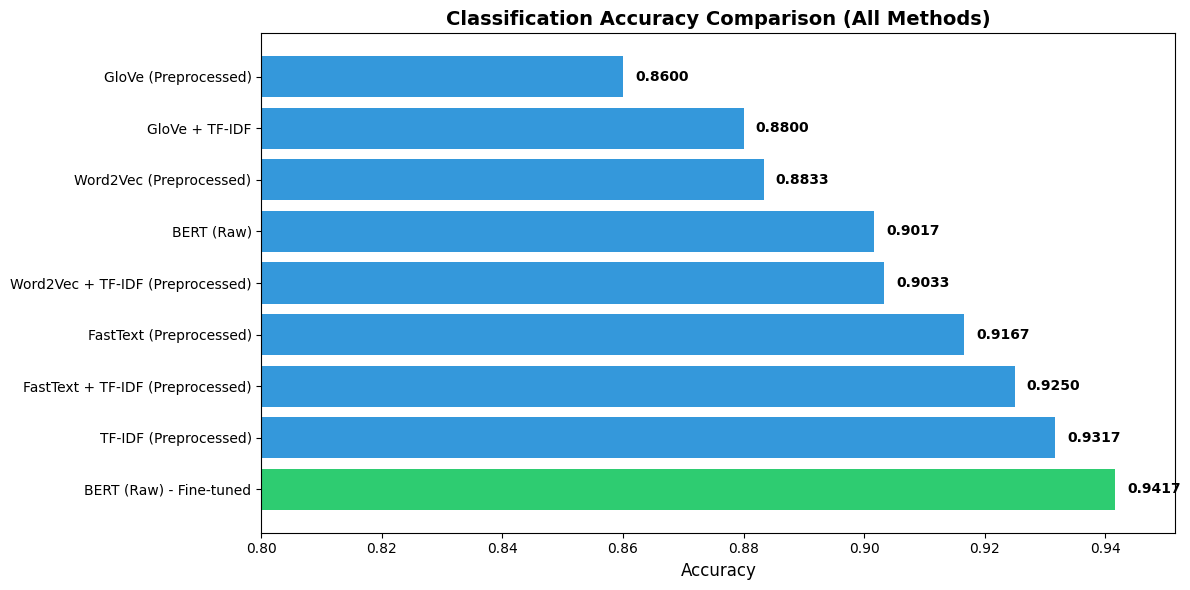


FINAL ACCURACY RESULTS (Sorted by Performance)
BERT (Raw) - Fine-tuned             → 0.9417
TF-IDF (Preprocessed)               → 0.9317
FastText + TF-IDF (Preprocessed)    → 0.9250
FastText (Preprocessed)             → 0.9167
Word2Vec + TF-IDF (Preprocessed)    → 0.9033
BERT (Raw)                          → 0.9017
Word2Vec (Preprocessed)             → 0.8833
GloVe + TF-IDF                      → 0.8800
GloVe (Preprocessed)                → 0.8600


In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame([
    {'Method': method, 'Accuracy': data['accuracy']} 
    for method, data in best_results.items()
]).sort_values('Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if x == results_df['Accuracy'].max() else '#3498db' for x in results_df['Accuracy']]
bars = ax.barh(results_df['Method'], results_df['Accuracy'], color=colors)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Classification Accuracy Comparison (All Methods)', fontsize=14, fontweight='bold')
ax.set_xlim([0.8, max(results_df['Accuracy']) + 0.01])

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FINAL ACCURACY RESULTS (Sorted by Performance)")
print("="*80)
for idx, row in results_df.iterrows():
    print(f"{row['Method']:35s} → {row['Accuracy']:.4f}")
print("="*80)

In [100]:
print("\n" + "="*100)
print("COMPLETE ACCURACY RESULTS SUMMARY")
print("="*100)

summary_data = [
    (method, data['accuracy'], data['classifier']) 
    for method, data in best_results.items()
]

print(f"\n{'Method':<35} {'Accuracy':<12} {'Best Classifier':<20}")
print("-"*100)

sorted_results = sorted(summary_data, key=lambda x: x[1], reverse=True)
for method, accuracy, classifier in sorted_results:
    marker = " ⭐ BEST" if accuracy == max(x[1] for x in sorted_results) else ""
    print(f"{method:<35} {accuracy:<12.4f} {classifier:<20}{marker}")

print("\n" + "="*100)
best_method = max(best_results.items(), key=lambda x: x[1]['accuracy'])
print(f"BEST OVERALL RESULT: {best_method[0]} achieves {best_method[1]['accuracy']:.4f} accuracy")
print("="*100)


COMPLETE ACCURACY RESULTS SUMMARY

Method                              Accuracy     Best Classifier     
----------------------------------------------------------------------------------------------------
BERT (Raw) - Fine-tuned             0.9417       BERT                 ⭐ BEST
TF-IDF (Preprocessed)               0.9317       Logistic Regression 
FastText + TF-IDF (Preprocessed)    0.9250       SVM                 
FastText (Preprocessed)             0.9167       SVM                 
Word2Vec + TF-IDF (Preprocessed)    0.9033       SVM                 
BERT (Raw)                          0.9017       SVM                 
Word2Vec (Preprocessed)             0.8833       Logistic Regression 
GloVe + TF-IDF                      0.8800       SVM                 
GloVe (Preprocessed)                0.8600       Logistic Regression 

BEST OVERALL RESULT: BERT (Raw) - Fine-tuned achieves 0.9417 accuracy
